# Agripredict

## Nom : Diene
## Prénom : Alioune Badara Médoune

### Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Chargement du dataset et nettoyage

In [2]:
df = pd.read_csv('../data/Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:

df.info()
print(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')


In [4]:
print(df["label"].unique())

<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str


In [5]:
# Vérifions le nombre de doublons dans le dataset

print("Doublons :", df.duplicated().sum())

Doublons : 0


In [6]:
# Vérifions le nombre de cultures et leur répartition

print(df['label'].nunique(), "cultures différentes")
df['label'].value_counts()

22 cultures différentes


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

### Création d'un champ de rendement kg/ha "yield_kg_ha" dans le dataset

In [7]:
'''
Le dataset ne contient pas de rendement réel car c'est un dataset de classification a la base.
Je vais donc simuler une variable continue. Le rendement dépend des nutriments et des conditions
climatiques à travers une somme pondérée et un peu de hasard
rendement = combinaison des nutriments + pluie + humidité, avec un poids pour chaque facteur et une
part de hasard

'''

np.random.seed(42) # cela va permettre que le résultat soit toujours le même si on relance

df["yield_kg_ha"] = (
    df["N"] * 15 +  #plus d'azote entraîne plus de rendement
    df["P"] * 10 +
    df["K"] * 10 +
    df["rainfall"] * 5 +    #plus de pluie entraîne plus de rendement  
    df["humidity"] * 8 +
    np.random.normal(0, 200, size=len(df)) #du bruit pour la variabilité naturelle des données
    
)

df[["N", "P", "K", "rainfall", "humidity", "yield_kg_ha"]].head()

,N,P,K,rainfall,humidity,yield_kg_ha
0,90,42,43,202.935536,82.002744,3970.042465
1,85,58,41,226.655537,80.319644,4013.181979
2,60,55,44,263.964248,82.320763,3997.925049
3,74,35,40,242.864034,80.158363,4020.193043
4,78,42,42,262.717340,81.604873,3929.595011


In [8]:
df["yield_kg_ha"].describe()

count    2200.000000
mean     2869.567618
std       975.010948
min      1061.377374
25%      2065.443646
50%      2724.283992
75%      3521.403418
max      5560.259881
Name: yield_kg_ha, dtype: float64

### Analyse exploratoire et graphiques

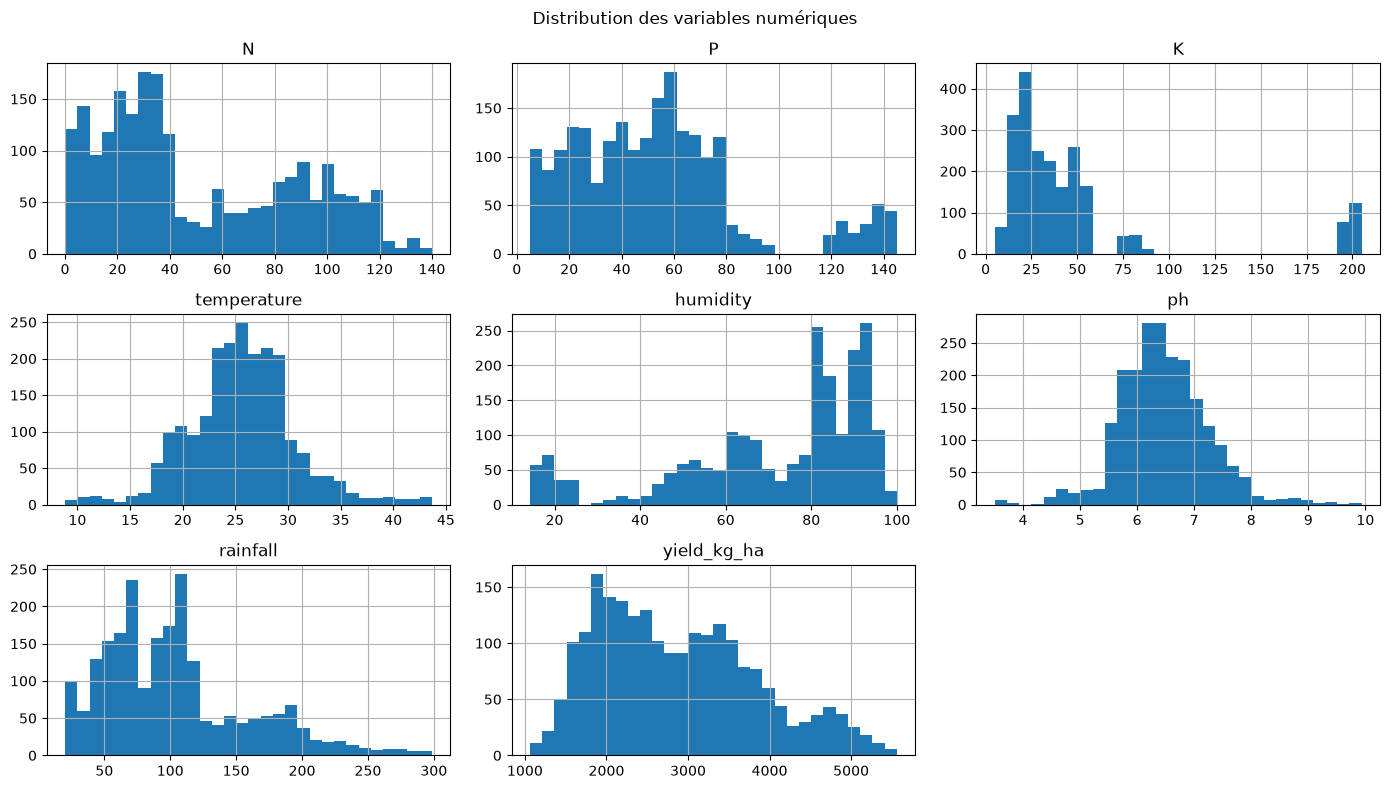

In [9]:
# Commençons par observer la distribution des variables numériques pour voir si elles sont équilibrées,
# ou si il y a des valeurs extrêmes, normales etc

colonnes_numeriques = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall", "yield_kg_ha"]

df[colonnes_numeriques].hist(figsize=(14, 8), bins=30)
plt.suptitle("Distribution des variables numériques")
plt.tight_layout()
plt.show()


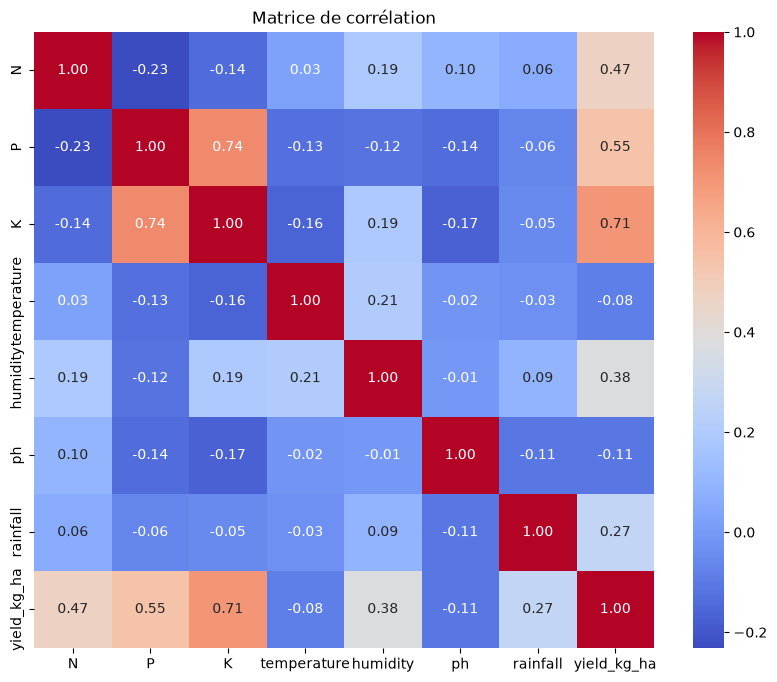

In [10]:
# Maintenant étudions la corrélation avec corr() qui calcule le coefficient de corrélation de Pearson
# entre chaque paire de variables, plus il est proche de 1, plus la corrélation est forte

correlation_matrix = df[colonnes_numeriques].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()


In [11]:
correlation_matrix['yield_kg_ha'].sort_values(ascending=False)

yield_kg_ha    1.000000
K              0.705022
P              0.546413
N              0.469641
humidity       0.377157
rainfall       0.273234
temperature   -0.083230
ph            -0.108210
Name: yield_kg_ha, dtype: float64

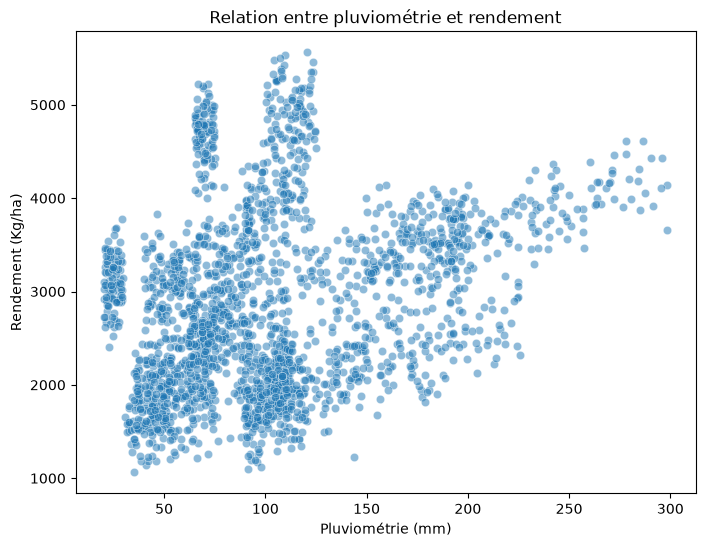

In [12]:
# Passons a la relation pluie/rendement
# Pour ce faire, nous allons utiliser scatterplot/nuage de point qui permet de voir visuellement
# s'il y a une tendance

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="rainfall", y="yield_kg_ha", alpha=0.5)
plt.title("Relation entre pluviométrie et rendement")
plt.xlabel("Pluviométrie (mm)")
plt.ylabel("Rendement (Kg/ha)")
plt.show()

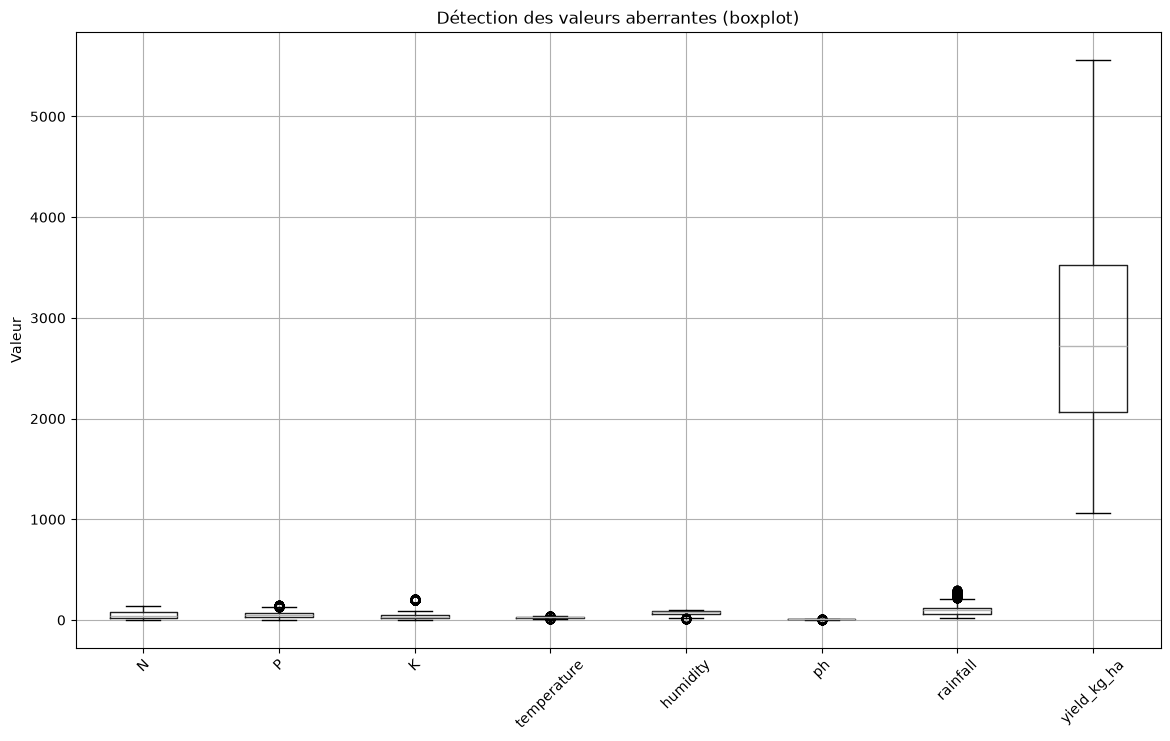

In [13]:
# Passons a la visualisation des outliers potentiels via boxplot
# Chaque boite montre la distribution d'une variable et ses valeurs extremes

plt.figure(figsize=(14, 8))
df[colonnes_numeriques].boxplot()
plt.xticks(rotation=45)
plt.title("Détection des valeurs aberrantes (boxplot)")
plt.ylabel("Valeur")
plt.show()

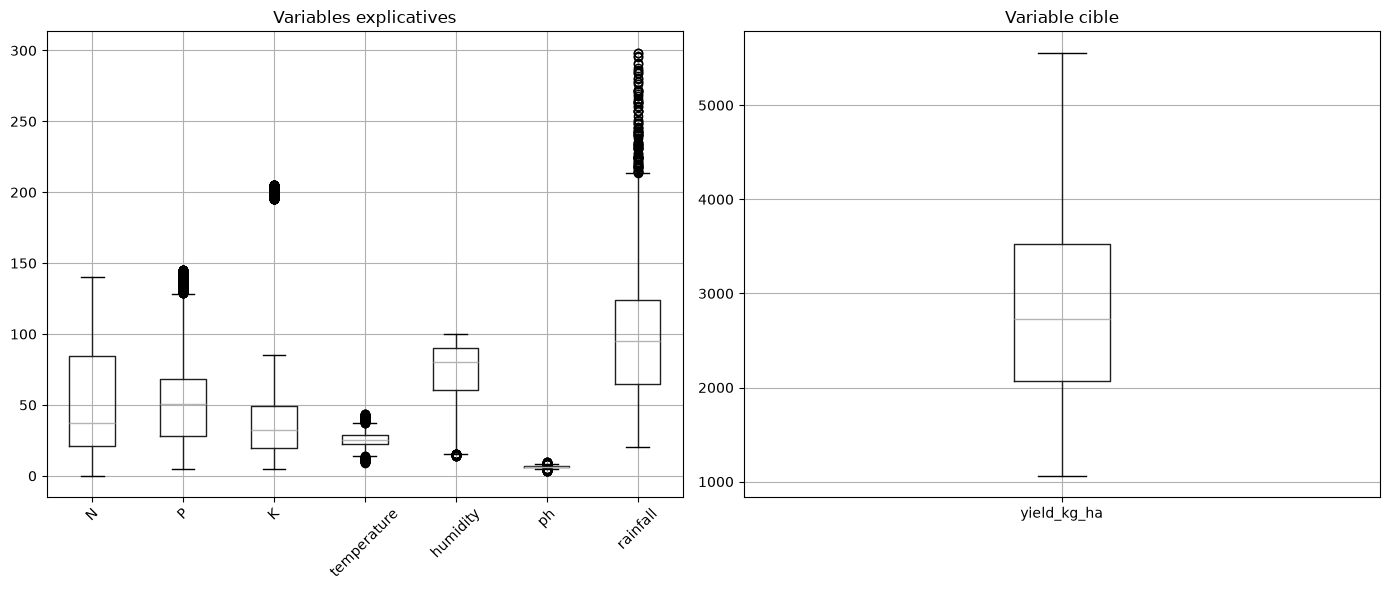

In [14]:
# On sépare les variables par échelle pour une lecture plus claire
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Groupe 1 : variables à petite échelle
df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']].boxplot(ax=axes[0])
axes[0].set_title("Variables explicatives")
axes[0].tick_params(axis='x', rotation=45)

# Groupe 2 : la variable cible, à part (échelle différente)
df[['yield_kg_ha']].boxplot(ax=axes[1])
axes[1].set_title("Variable cible")

plt.tight_layout()
plt.show()

### Prétraitement

In [15]:
# Avant d'entraîner un modéle, il faut transformer les données dans un format que scikit-learn peut utiliser, donc pour ce faire,
# nous allons encoder la variable "label" car les modéles ne comprennent que des nombres, pas du texte comme "rice" ou "apple".
# On transforme donc chaque nom de culture en variable numérique
# Pour l'encodage, nous allons utiliser la méthode One-Hot Encoding pour éviter que le modéle qu'il existe un ordre ou une distance
# entre les catégories

df_encoded = pd.get_dummies(df, columns=["label"], prefix="label") # pd.get_dummies() transforme chaque catégorie en colonne binaire séparée
# Exemple : label='rice' devient une colonne 'label_rice'=1 et toutes les autres colonnes 'label_xxx'=0

# Aprés cette ligne, nous devons normalement avoir 22 nouvelles colonnes

print(df_encoded.shape)
df_encoded.head()

(2200, 30)


,N,P,K,temperature,humidity,ph,rainfall,yield_kg_ha,label_apple,label_banana,...,label_mango,label_mothbeans,label_mungbean,label_muskmelon,label_orange,label_papaya,label_pigeonpeas,label_pomegranate,label_rice,label_watermelon
0,90,42,43,20.879744,82.002744,6.502985,202.935536,3970.042465,False,False,...,False,False,False,False,False,False,False,False,True,False
1,85,58,41,21.770462,80.319644,7.038096,226.655537,4013.181979,False,False,...,False,False,False,False,False,False,False,False,True,False
2,60,55,44,23.004459,82.320763,7.840207,263.964248,3997.925049,False,False,...,False,False,False,False,False,False,False,False,True,False
3,74,35,40,26.491096,80.158363,6.980401,242.864034,4020.193043,False,False,...,False,False,False,False,False,False,False,False,True,False
4,78,42,42,20.130175,81.604873,7.628473,262.717340,3929.595011,False,False,...,False,False,False,False,False,False,False,False,True,False


In [16]:
# Maintenant on peut séparer les variables explicatives (variables utilisées pour la prédiction) de la variable cible yield_kg_ha 
# (celle qu'on veut prédire)

X = df_encoded.drop(columns=["yield_kg_ha"])
y = df_encoded["yield_kg_ha"]

print("Forme de X : ", X.shape)
print("Forme de y : ", y.shape)

Forme de X :  (2200, 29)
Forme de y :  (2200,)


In [17]:
# Pour l'entrainement, nous avons choisi une répartition de 80% données train et 20% données test, soit 0.2 en test_size et 
# un random_state = 42 pour avoir le même résultat aprés relance

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print("Taille des données train : ", X_train.shape[0], "lignes")
print("Taille des données test : ", X_test.shape[0], "lignes")

Taille des données train :  1760 lignes
Taille des données test :  440 lignes


### Modélisation

In [18]:
# Baseline : Régression linéaire
# C'est un modéle simple qui cherche une relation linéaire entre les variables explicatives (X) et le rendement (y)


from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train) # la méthode .fit() permet d'entraîner un modéle sur les données d'entrainement
y_pred_linear_regression = linear_regression.predict(X_test) # la méthode .predict() utilise le modéle entraîné pour prédire sur les données 
# test qui sont des données que le modéle n'a jamais vues pendant l'entraînement
print("Prédiction du modéle de Régression linéaire générées")


Prédiction du modéle de Régression linéaire générées


In [19]:
# Modéle avancé : Random Forest Regressor
# Random Forest combine plusieurs arbres de décision (une forêt) et fait la moyenne de leurs prédictions
# Il capture des relations non-linéaires que la régréssion linéaire ne peut pas voir

from sklearn.ensemble import RandomForestRegressor

random_forest_regressor = RandomForestRegressor(n_estimators=100, random_state=42) #n_estimators représente le nombre d'arbres dans la forêt
random_forest_regressor.fit(X_train, y_train)
y_pred_random_forest_regressor = random_forest_regressor.predict(X_test)
print("Prédiction du modéle de Random Forest Regressor générées")


Prédiction du modéle de Random Forest Regressor générées


### Évaluation des modéles

In [20]:
# Pour comparer les modéles, nous avons crées une fonction qui sera ensuite appelée qui affichera les métriques

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluer_model (y_true, y_pred, nom_model) : 
    '''
    y_true : les valeurs réelles de rendement (y_test)
    y_pred : les valeurs prédites par le modéle
    nom_model : le nom du modéle évalué
    '''
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Nous avons choisi d'utiliser mean_sqared_error car il est présent dans toute les verisons de scikit-learn contrairement 
    # à root_mean_sqared_error qui est présente que dans les récentes versions, 
    # donc pour avoir le RMSE, il faut appliquer la racine carrée au MSE
    
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {nom_model} ---")
    print(f"MAE : {mae:.2f} Kg/ha")
    print(f"RMSE : {rmse:.2f} Kg/ha")
    print(f"R² : {r2:.4f} ")
    print()
    
    return {"Modéle": nom_model, "MAE": mae, "RMSE": rmse, "R2": r2}

# Évaluation des 2 modéles
result_linear_regression = evaluer_model(y_test, y_pred_linear_regression, "Régression Linéaire")
result_random_forest_regressor = evaluer_model(y_test, y_pred_random_forest_regressor, "Random Forest Regressor")
    

--- Régression Linéaire ---
MAE : 155.69 Kg/ha
RMSE : 197.81 Kg/ha
R² : 0.9569 

--- Random Forest Regressor ---
MAE : 176.89 Kg/ha
RMSE : 224.42 Kg/ha
R² : 0.9446 



In [21]:
# Tableau récapitulatif pour comparer facilement les deux modèles
comparaison = pd.DataFrame([result_linear_regression, result_random_forest_regressor])
comparaison

,Modéle,MAE,RMSE,R2
0,Régression Linéaire,155.692565,197.813714,0.956932
1,Random Forest Regressor,176.889258,224.422722,0.944566


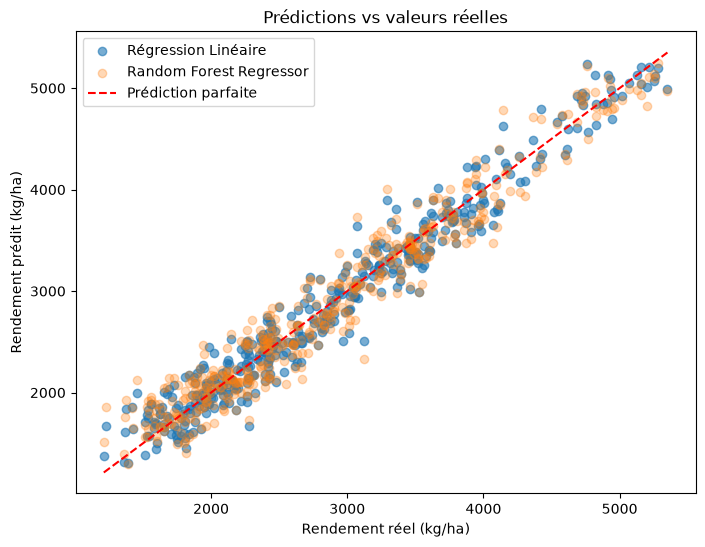

In [22]:
# Graphique : prédictions vs vraies valeurs
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_linear_regression, alpha=0.6, label='Régression Linéaire')
plt.scatter(y_test, y_pred_random_forest_regressor, alpha=0.3, label='Random Forest Regressor')

# Ligne diagonale = prédiction parfaite (y_pred = y_true)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', label='Prédiction parfaite')

plt.xlabel("Rendement réel (kg/ha)")
plt.ylabel("Rendement prédit (kg/ha)")
plt.title("Prédictions vs valeurs réelles")
plt.legend()
plt.show()

### Analyse des erreurs

In [27]:
X_test.index

Index([1451, 1334, 1761, 1735, 1576, 1110, 1594,  530,  651,  819,
       ...
        964,  308, 1307,  617,  787,   59,   71, 1908, 1958,  482],
      dtype='int64', length=440)

In [ ]:
# Pour faire l'analyse des erreurs, on va calculer l'erreur absolue (différence entre les valeurs réelles et prédites) pour chaque ligne.
# Pour ce faire, nous allons utiliser les index conservés par le train_test_split pour récupérer les labels d'origine avant le One Hot-encoding

labels_test = df.loc[X_test.index, "label"] # Cette ligne de code permet de chercher dans df, les lignes dont l'index est dans la liste
# X_test.index et de récupérer leur label.

# Maintenant on peut construire un tableau d'analyse en utilisant les prédictions du meilleur modéle (régréssion linéaire)

analyse_erreurs = pd.DataFrame({
    "culture" : labels_test.values,
    "rendement_reel" : y_test.values,
    "rendement_predit" : y_pred_linear_regression
})

analyse_erreurs["erreur_absolue"] = abs(analyse_erreurs["rendement_reel"] - analyse_erreurs["rendement_predit"])
analyse_erreurs


,culture,rendement_reel,rendement_predit,erreur_absolue
0,muskmelon,3384.822540,3097.285823,287.536717
1,watermelon,3029.066687,2988.751714,40.314972
2,papaya,3464.131184,3308.096280,156.034904
3,papaya,2703.885197,3025.669968,321.784772
4,apple,4815.634005,5132.927518,317.293513
...,...,...,...,...
435,rice,4611.834037,4395.882775,215.951263
436,rice,4104.410346,3787.873535,316.536811
437,cotton,3203.070895,3466.617143,263.546248
438,cotton,3599.586139,3395.635128,203.951012


In [ ]:
# Calculons l'erreur moyenne par culture

erreur_par_culture = analyse_erreurs.groupby("culture")["erreur_absolue"].mean().sort_values(ascending=False)
erreur_par_culture

culture
pigeonpeas     201.513387
banana         184.118028
rice           183.791005
coconut        178.842884
mango          175.964005
apple          173.501815
mungbean       171.214012
coffee         163.560250
jute           158.464481
cotton         156.007123
mothbeans      154.324696
chickpea       154.075863
muskmelon      146.221278
pomegranate    144.603052
grapes         139.627853
kidneybeans    137.427224
lentil         136.922557
orange         136.818183
maize          129.053268
blackgram      127.393627
watermelon     123.718800
papaya         120.148698
Name: erreur_absolue, dtype: float64

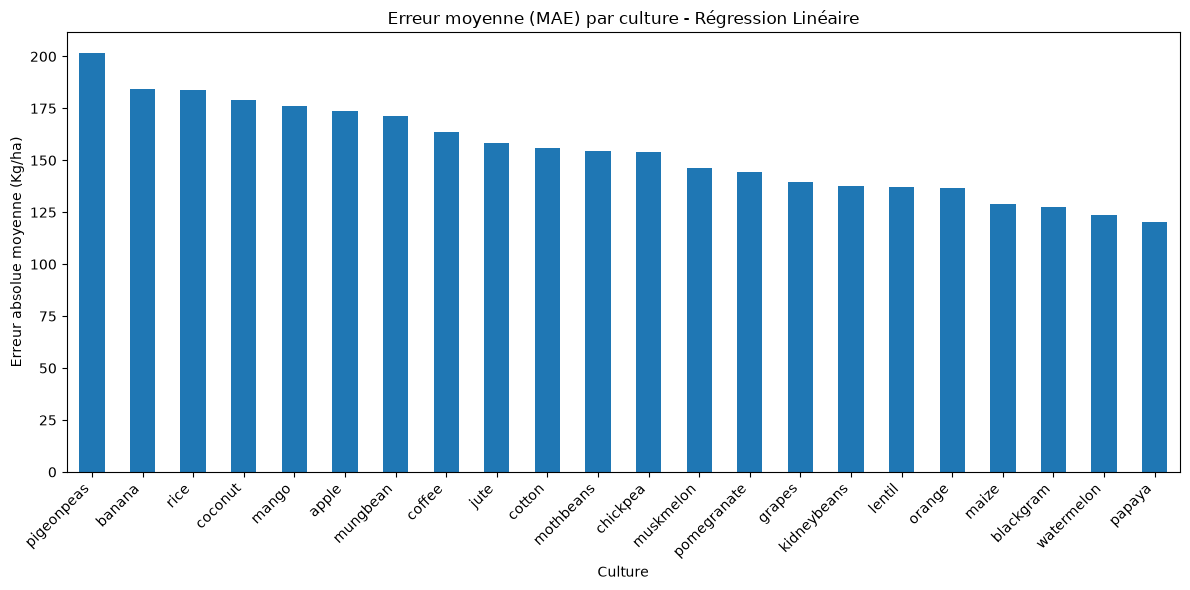

In [31]:
# Passons a la visualisation

plt.figure(figsize=(12, 6))
erreur_par_culture.plot(kind='bar')
plt.title("Erreur moyenne (MAE) par culture - Régression Linéaire")
plt.xlabel("Culture")
plt.ylabel("Erreur absolue moyenne (Kg/ha)")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

In [32]:
# On compare l'erreur moyenne par culture avec le rendement moyen et l'écart-type par culture
stats_par_culture = df.groupby('label')['yield_kg_ha'].agg(['mean', 'std'])
stats_par_culture['erreur_moyenne'] = erreur_par_culture

stats_par_culture.sort_values('erreur_moyenne', ascending=False)

,mean,std,erreur_moyenne
label,,,
pigeonpeas,2311.729990,372.996327,201.513387
banana,4022.084765,273.821905,184.118028
rice,3891.168837,308.266652,183.791005
coconut,2432.254063,319.300682,178.842884
mango,1768.243481,298.836293,175.964005
apple,4935.211596,299.336504,173.501815
mungbean,1917.186574,304.774221,171.214012
coffee,3362.066904,313.758659,163.560250
jute,3533.262016,259.152703,158.464481


In [34]:
# Écart-type des variables d'entrée par culture
# (pour vérifier si les cultures avec le plus d'erreur ont aussi
# les variables les plus dispersées)
dispersion_par_culture = df.groupby('label')[['N', 'P', 'K', 'rainfall', 'humidity']].std()
dispersion_par_culture['erreur_moyenne'] = erreur_par_culture

dispersion_par_culture.sort_values('erreur_moyenne', ascending=False)

,N,P,K,rainfall,humidity,erreur_moyenne
label,,,,,,
pigeonpeas,11.849950,7.294463,2.815165,32.986321,10.963659,201.513387
banana,11.107241,7.690339,3.382591,9.398150,2.805481,184.118028
rice,11.917981,7.904966,2.946167,34.291825,1.418381,183.791005
coconut,11.761931,8.357244,2.998636,29.472333,2.686329,178.842884
mango,12.329037,7.663873,3.096691,3.338577,2.756285,175.964005
apple,11.863704,8.139665,3.320871,7.102985,1.458551,173.501815
mungbean,11.510641,7.870261,3.148368,7.117214,2.851356,171.214012
coffee,12.345203,7.276113,3.246817,25.695086,5.838566,163.560250
jute,10.968274,7.195706,3.313563,15.078367,5.507798,158.464481


### Sauvegarde du modéle entraîné

In [35]:
import joblib

# Sauvegarde du modéle entraîné dans le dossier models/ pour pouvoir le recharger sans réentrainement

joblib.dump(linear_regression, "../models/best_model.pkl")

# Sauvegarde des colonnes utilisées par le modéle puisque le One-Hot Encoding a crée des colonnes spécifiques 

colonnes_modele = X_train.columns.tolist()
joblib.dump(colonnes_modele, "../models/colonnes.pkl")
print("Modéle et colonnes sauvegardés dans le dossier models/")

Modéle et colonnes sauvegardés dans le dossier models/
